# Cross-Province Model Comparison

Compares TFT, XGBoost, and Stacking Ensemble solar forecast performance across three Spanish provinces:
- **Cáceres** (Extremadura) — inland, semi-arid, 2,463 MWp top-8
- **Cádiz** (Andalucía) — coastal lowland, 715 MWp top-8
- **Zaragoza** (Aragón) — Ebro valley, 462 MWp top-8

For each province, six model variants were trained:

**TFT (Temporal Fusion Transformer)** — sequence model with 168h encoder:
1. **Standard** — weather as observed (encoder-only), decoder sees 9 known-future features
2. **NWP** — Open-Meteo forecasts as known-future (encoder + decoder), decoder sees 16 known-future features
3. **Perfect forecast** — ERA5 reanalysis as known-future (performance ceiling)

**XGBoost** — tabular baseline (no sequences, current-timestep features only):
4. **Standard** — 9 known-future features only (calendar + solar geometry, same as TFT decoder)
5. **NWP** — 16 known-future features only (calendar + solar + NWP forecasts, same as TFT NWP decoder)

**Fair comparison constraint:** XGBoost only uses features available at forecast time — no observed
ERA5 weather at the target timestep. This ensures a fair comparison with TFT, which only sees
observed weather in its encoder (past 168h), never in its decoder (future 24h).

**Stacking Ensemble** — combines TFT NWP + XGBoost NWP via Ridge Regression:
6. **Stacking** — meta-learner trained on validation predictions from both base models

**Key questions:**
- Does TFT's temporal modelling add value over a simpler tabular baseline?
- Does the NWP improvement pattern hold across provinces and model types?
- Does stacking improve over the best individual model?

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. Province Configuration

In [2]:
# Province definitions
PROVINCES = {
    'Cáceres': {
        'dir': 'caceres',
        'capacity_mwp': 2463.01,
        'n_plants': 8,
        'region': 'Extremadura',
        'climate': 'Inland semi-arid',
    },
    'Cádiz': {
        'dir': 'cadiz',
        'capacity_mwp': 714.60,
        'n_plants': 8,
        'region': 'Andalucía',
        'climate': 'Coastal lowland',
    },
    'Zaragoza': {
        'dir': 'zaragoza',
        'capacity_mwp': 462.40,
        'n_plants': 8,
        'region': 'Aragón',
        'climate': 'Ebro valley continental',
    },
}

# Navigate to project root
PROJECT_ROOT = os.getcwd()
# If running from a subdirectory, try to find the project root
if not os.path.isdir(os.path.join(PROJECT_ROOT, 'caceres')):
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')
for name, info in PROVINCES.items():
    exists = os.path.isdir(os.path.join(PROJECT_ROOT, info['dir']))
    print(f"  {name:12s}  {info['dir']:25s}  exists={exists}")

Project root: c:\Users\nicol\Documents\ML-solar-forecast
  Cáceres       caceres                    exists=True
  Cádiz         cadiz                      exists=True
  Zaragoza      zaragoza                   exists=True


## 2. Load Results

In [3]:
def load_metrics(province_dir, json_paths, metrics_key, fallback_key):
    """Load metrics from a JSON results file. Tries multiple paths.
    Returns dict with R2, RMSE_MWh, MAE_MWh or None."""
    if isinstance(json_paths, str):
        json_paths = [json_paths]
    for json_path in json_paths:
        full_path = os.path.join(PROJECT_ROOT, province_dir, json_path)
        if os.path.exists(full_path):
            with open(full_path) as f:
                data = json.load(f)
            metrics = data.get(metrics_key) or data.get(fallback_key)
            if metrics:
                print(f'  Found: {province_dir}/{json_path} -> {list(metrics.keys())}')
                return metrics
    return None


def get_peak_generation(province_dir, province_name):
    """Get peak hourly generation from the assembled dataset (= ESIOS total provincial PV)."""
    csv_name = province_name.lower() + '_assembled_dataset.csv'
    csv_path = os.path.join(PROJECT_ROOT, province_dir, 'data', csv_name)
    df = pd.read_csv(csv_path, usecols=['pv_generation_gwh'])  # column name is gwh but unit is MWh
    return df['pv_generation_gwh'].max()


# Model variants and where their results are stored
# Multiple candidate paths per model to handle naming differences across provinces
MODELS = {
    'TFT Standard': {
        'json': ['models/standard/hp_study_results.json'],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
    'TFT NWP': {
        'json': [
            'models/nwp_forecast/nwp_hp_study_results.json',  # Cádiz/Zaragoza naming
            'models/nwp_forecast/hp_study_results.json',       # alternative naming
        ],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
    'TFT Perfect Forecast': {
        'json': ['models/perfect_forecast/hp_study_results_pf.json'],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
    'XGBoost Standard': {
        'json': ['models/xgboost/xgboost_hp_study_results.json'],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
    'XGBoost NWP': {
        'json': ['models/xgboost/xgboost_nwp_hp_study_results.json'],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
    'Stacking Ensemble': {
        'json': ['models/stacking_results.json'],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'test_metrics_mwh',
    },
}

# Collect all results + compute peak generation per province for proper nRMSE
rows = []
for prov_name, prov_info in PROVINCES.items():
    print(f'\n{prov_name}:')
    
    # Get peak generation from ESIOS data (total provincial PV, not just top-8)
    peak_gen = get_peak_generation(prov_info['dir'], prov_name.replace('á', 'a').replace('é', 'e'))
    prov_info['peak_gen_mwh'] = peak_gen
    print(f'  Peak ESIOS generation: {peak_gen:.1f} MWh  (top-8 capacity: {prov_info["capacity_mwp"]:.0f} MWp, ratio: {peak_gen/prov_info["capacity_mwp"]:.2f}x)')
    
    for model_name, model_info in MODELS.items():
        metrics = load_metrics(
            prov_info['dir'],
            model_info['json'],
            model_info['metrics_key'],
            model_info['fallback_key'],
        )
        if metrics:
            rows.append({
                'Province': prov_name,
                'Model': model_name,
                'R2': metrics.get('R2'),
                'RMSE_MWh': metrics.get('RMSE_MWh'),
                'MAE_MWh': metrics.get('MAE_MWh'),
                'Capacity_MWp': prov_info['capacity_mwp'],
                'Peak_Gen_MWh': peak_gen,
            })
        else:
            print(f'  MISSING: {model_name}')
            rows.append({
                'Province': prov_name,
                'Model': model_name,
                'R2': None, 'RMSE_MWh': None, 'MAE_MWh': None,
                'Capacity_MWp': prov_info['capacity_mwp'],
                'Peak_Gen_MWh': peak_gen,
            })

results = pd.DataFrame(rows)

# nRMSE normalized by peak observed generation (fair cross-province comparison)
# This accounts for the fact that ESIOS covers ALL provincial PV, not just the top-8 plants
results['nRMSE_pct'] = (results['RMSE_MWh'] / results['Peak_Gen_MWh'] * 100).round(2)

n_found = results['R2'].notna().sum()
n_total = len(results)
print(f'\nLoaded {n_found}/{n_total} model results ({n_total - n_found} missing)')
results


Cáceres:
  Peak ESIOS generation: 2959.8 MWh  (top-8 capacity: 2463 MWp, ratio: 1.20x)
  Found: caceres/models/standard/hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: caceres/models/nwp_forecast/nwp_hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: caceres/models/perfect_forecast/hp_study_results_pf.json -> ['RMSE_MWh', 'MAE_MWh', 'R2']
  Found: caceres/models/xgboost/xgboost_hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2', 'nRMSE_pct']
  Found: caceres/models/xgboost/xgboost_nwp_hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2', 'nRMSE_pct']
  Found: caceres/models/stacking_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2', 'nRMSE_pct']

Cádiz:
  Peak ESIOS generation: 1480.6 MWh  (top-8 capacity: 715 MWp, ratio: 2.07x)
  Found: cadiz/models/standard/hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: cadiz/models/nwp_forecast/nwp_hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: cadiz/models/perfect_forecast/hp_study_resu

,Province,Model,R2,RMSE_MWh,MAE_MWh,Capacity_MWp,Peak_Gen_MWh,nRMSE_pct
0,Cáceres,TFT Standard,0.833785,290.967123,149.245250,2463.01,2959.799,9.83
1,Cáceres,TFT NWP,0.890510,236.154218,119.299275,2463.01,2959.799,7.98
2,Cáceres,TFT Perfect Forecast,0.875655,251.664594,120.739292,2463.01,2959.799,8.50
3,Cáceres,XGBoost Standard,0.800821,318.515511,173.962372,2463.01,2959.799,10.76
4,Cáceres,XGBoost NWP,0.892699,233.781213,120.397809,2463.01,2959.799,7.90
5,Cáceres,Stacking Ensemble,0.784206,331.534408,173.681873,2463.01,2959.799,11.20
6,Cádiz,TFT Standard,0.658251,266.289477,157.896115,714.60,1480.592,17.99
7,Cádiz,TFT NWP,0.750382,227.582271,128.708004,714.60,1480.592,15.37
8,Cádiz,TFT Perfect Forecast,0.649567,269.651458,157.904844,714.60,1480.592,18.21
9,Cádiz,XGBoost Standard,0.714535,243.375458,145.010242,714.60,1480.592,16.44


## 3. Per-Province Comparison

In [4]:
for prov_name in PROVINCES:
    prov_results = results[results['Province'] == prov_name].copy()
    cap = PROVINCES[prov_name]['capacity_mwp']
    climate = PROVINCES[prov_name]['climate']
    
    print('=' * 80)
    print(f'SIX-WAY COMPARISON — {prov_name} ({climate}, {cap:.0f} MWp)')
    print('=' * 80)
    print(f'{"Model":35s} {"RMSE (MWh)":>12s} {"MAE (MWh)":>11s} {"R²":>8s} {"nRMSE %":>8s}')
    print('-' * 80)
    
    for _, row in prov_results.iterrows():
        if row['R2'] is not None and not pd.isna(row['R2']):
            print(f'{row["Model"]:35s} {row["RMSE_MWh"]:>12.2f} {row["MAE_MWh"]:>11.2f} {row["R2"]:>8.4f} {row["nRMSE_pct"]:>7.2f}%')
        else:
            print(f'{row["Model"]:35s} {"—":>12s} {"—":>11s} {"—":>8s} {"—":>8s}')
    
    # Extract R² per model
    def get_r2(model_name):
        v = prov_results.loc[prov_results['Model'] == model_name, 'R2'].values
        return v[0] if len(v) and pd.notna(v[0]) else None

    tft_std = get_r2('TFT Standard')
    tft_nwp = get_r2('TFT NWP')
    tft_pf  = get_r2('TFT Perfect Forecast')
    xgb_std = get_r2('XGBoost Standard')
    xgb_nwp = get_r2('XGBoost NWP')
    stack   = get_r2('Stacking Ensemble')

    print()
    # TFT inter-model deltas
    if tft_std is not None and tft_nwp is not None:
        print(f'  TFT: NWP vs Standard:         ΔR² = {tft_nwp - tft_std:+.4f}')
    if tft_std is not None and tft_pf is not None:
        print(f'  TFT: Perfect vs Standard:     ΔR² = {tft_pf - tft_std:+.4f}')

    # XGBoost inter-model deltas
    if xgb_std is not None and xgb_nwp is not None:
        print(f'  XGB: NWP vs Standard:         ΔR² = {xgb_nwp - xgb_std:+.4f}')

    # TFT vs XGBoost (same feature set)
    if tft_std is not None and xgb_std is not None:
        print(f'  TFT Standard vs XGB Standard: ΔR² = {tft_std - xgb_std:+.4f}')
    if tft_nwp is not None and xgb_nwp is not None:
        print(f'  TFT NWP vs XGB NWP:           ΔR² = {tft_nwp - xgb_nwp:+.4f}')

    # Stacking improvement
    if stack is not None:
        best_individual = max(filter(None, [tft_nwp, xgb_nwp]))
        best_name = 'TFT NWP' if (tft_nwp or 0) > (xgb_nwp or 0) else 'XGBoost NWP'
        print(f'  Stacking vs {best_name}:  ΔR² = {stack - best_individual:+.4f}')
    print()

SIX-WAY COMPARISON — Cáceres (Inland semi-arid, 2463 MWp)
Model                                 RMSE (MWh)   MAE (MWh)       R²  nRMSE %
--------------------------------------------------------------------------------
TFT Standard                              290.97      149.25   0.8338    9.83%
TFT NWP                                   236.15      119.30   0.8905    7.98%
TFT Perfect Forecast                      251.66      120.74   0.8757    8.50%
XGBoost Standard                          318.52      173.96   0.8008   10.76%
XGBoost NWP                               233.78      120.40   0.8927    7.90%
Stacking Ensemble                         331.53      173.68   0.7842   11.20%

  TFT: NWP vs Standard:         ΔR² = +0.0567
  TFT: Perfect vs Standard:     ΔR² = +0.0419
  XGB: NWP vs Standard:         ΔR² = +0.0919
  TFT Standard vs XGB Standard: ΔR² = +0.0330
  TFT NWP vs XGB NWP:           ΔR² = -0.0022
  Stacking vs XGBoost NWP:  ΔR² = -0.1085

SIX-WAY COMPARISON — Cádiz (Coasta

## 4. Cross-Province Pivot Table

In [5]:
# Pivot: provinces as rows, models as columns
available = results.dropna(subset=['R2'])

if len(available) > 0:
    pivot_r2 = available.pivot(index='Province', columns='Model', values='R2')
    pivot_rmse = available.pivot(index='Province', columns='Model', values='RMSE_MWh')
    pivot_nrmse = available.pivot(index='Province', columns='Model', values='nRMSE_pct')

    # Reorder columns: XGBoost first, then TFT, then Stacking
    col_order = ['XGBoost Standard', 'XGBoost NWP', 'TFT Standard', 'TFT NWP', 'TFT Perfect Forecast', 'Stacking Ensemble']
    col_order = [c for c in col_order if c in pivot_r2.columns]

    print('=== R² by Province and Model ===')
    print(pivot_r2[col_order].round(4).to_string())

    print('\n=== RMSE (MWh) by Province and Model ===')
    print(pivot_rmse[col_order].round(2).to_string())

    print('\n=== nRMSE (% of peak observed generation) by Province and Model ===')
    print(pivot_nrmse[col_order].round(2).to_string())
else:
    print('No results available yet. Run the training/evaluation pipelines first.')

=== R² by Province and Model ===
Model     XGBoost Standard  XGBoost NWP  TFT Standard  TFT NWP  TFT Perfect Forecast  Stacking Ensemble
Province                                                                                               
Cáceres             0.8008       0.8927        0.8338   0.8905                0.8757             0.7842
Cádiz               0.7145       0.7615        0.6583   0.7504                0.6496             0.9354
Zaragoza            0.8133       0.8906        0.8501   0.8969                0.8935             0.9067

=== RMSE (MWh) by Province and Model ===
Model     XGBoost Standard  XGBoost NWP  TFT Standard  TFT NWP  TFT Perfect Forecast  Stacking Ensemble
Province                                                                                               
Cáceres             318.52       233.78        290.97   236.15                251.66             331.53
Cádiz               243.38       222.45        266.29   227.58                269.65         

## 5. Visualizations

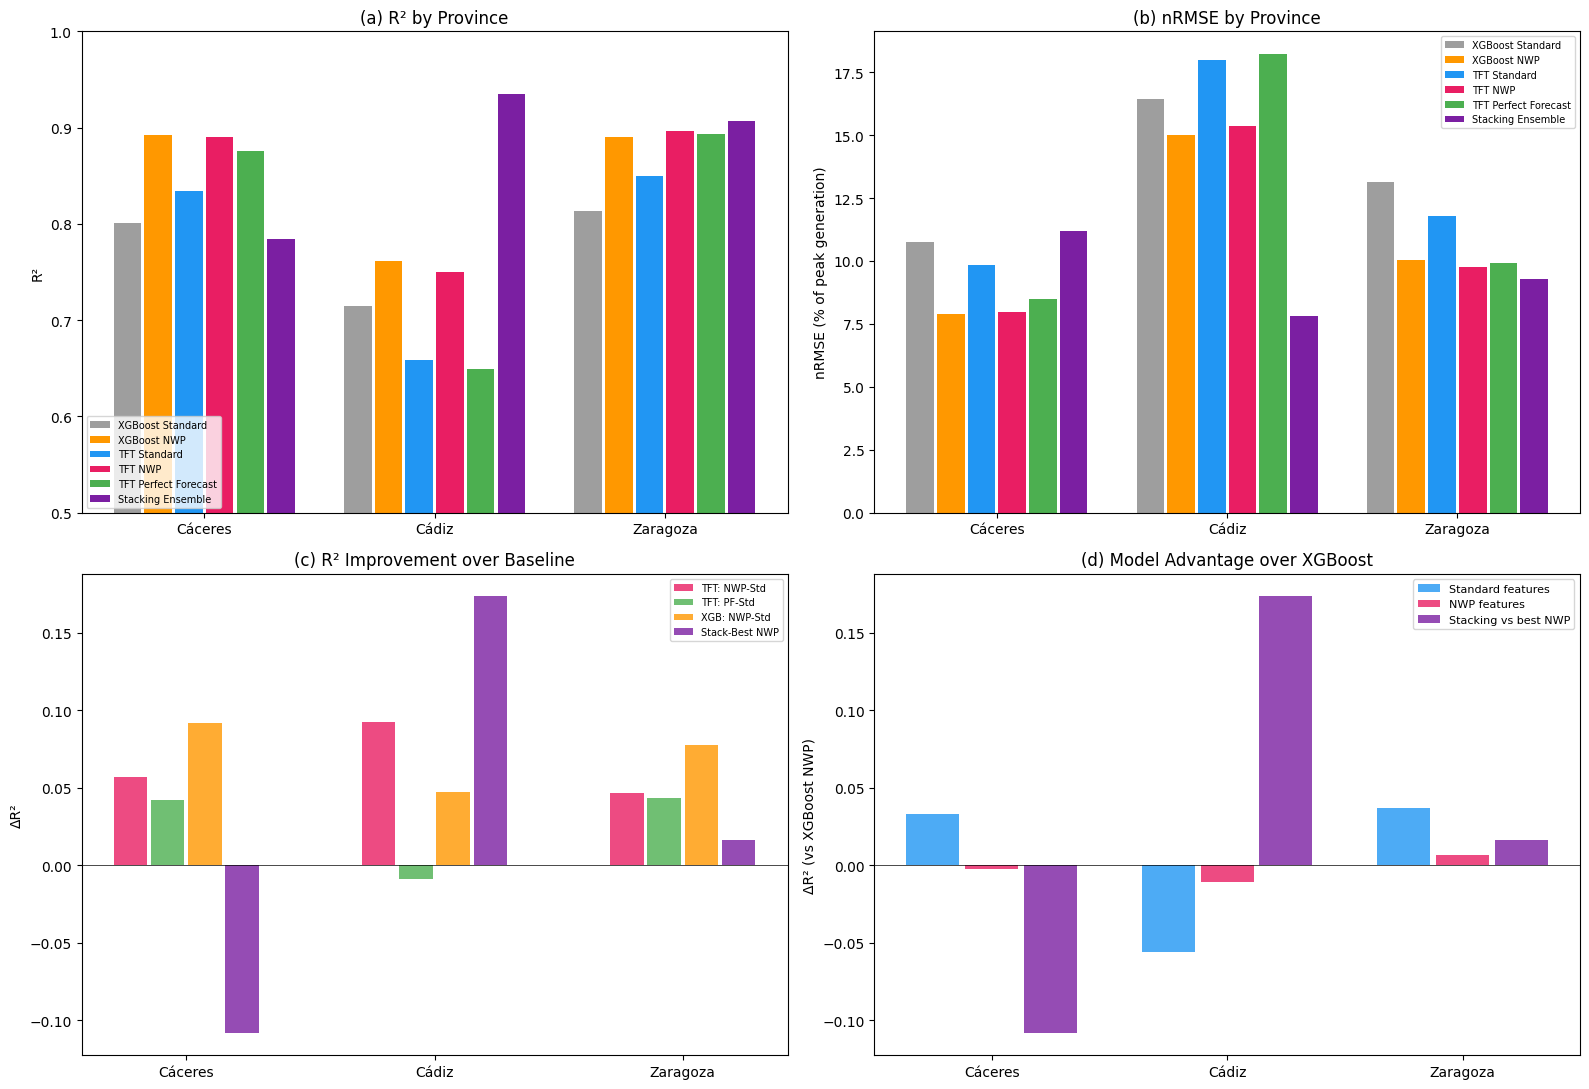

In [6]:
available = results.dropna(subset=['R2'])

if len(available) >= 3:  # Need at least one province with results
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    col_order = ['XGBoost Standard', 'XGBoost NWP', 'TFT Standard', 'TFT NWP', 'TFT Perfect Forecast', 'Stacking Ensemble']
    col_order = [c for c in col_order if c in available['Model'].values]
    color_map = {
        'XGBoost Standard': '#9E9E9E',
        'XGBoost NWP': '#FF9800',
        'TFT Standard': '#2196F3',
        'TFT NWP': '#E91E63',
        'TFT Perfect Forecast': '#4CAF50',
        'Stacking Ensemble': '#7B1FA2',
    }
    colors = [color_map.get(c, '#333333') for c in col_order]
    prov_names = list(PROVINCES.keys())
    n_models = len(col_order)
    bar_width = 0.8 / n_models

    # (a) R² comparison
    for i, model in enumerate(col_order):
        vals = []
        for prov in prov_names:
            row = available[(available['Province'] == prov) & (available['Model'] == model)]
            vals.append(row['R2'].values[0] if len(row) > 0 else 0)
        x = np.arange(len(prov_names)) + i * bar_width
        axes[0, 0].bar(x, vals, bar_width * 0.9, label=model, color=colors[i])
    axes[0, 0].set_xticks(np.arange(len(prov_names)) + bar_width * (n_models - 1) / 2)
    axes[0, 0].set_xticklabels(prov_names)
    axes[0, 0].set_ylabel('R²')
    axes[0, 0].set_title('(a) R² by Province')
    axes[0, 0].legend(fontsize=7, loc='lower left')
    axes[0, 0].set_ylim(0.5, 1.0)

    # (b) nRMSE comparison
    for i, model in enumerate(col_order):
        vals = []
        for prov in prov_names:
            row = available[(available['Province'] == prov) & (available['Model'] == model)]
            vals.append(row['nRMSE_pct'].values[0] if len(row) > 0 else 0)
        x = np.arange(len(prov_names)) + i * bar_width
        axes[0, 1].bar(x, vals, bar_width * 0.9, label=model, color=colors[i])
    axes[0, 1].set_xticks(np.arange(len(prov_names)) + bar_width * (n_models - 1) / 2)
    axes[0, 1].set_xticklabels(prov_names)
    axes[0, 1].set_ylabel('nRMSE (% of peak generation)')
    axes[0, 1].set_title('(b) nRMSE by Province')
    axes[0, 1].legend(fontsize=7)

    # (c) ΔR² — NWP improvement for both model types + stacking
    x = np.arange(len(prov_names))
    bar_w = 0.15
    delta_items = [
        ('TFT: NWP-Std', 'TFT Standard', 'TFT NWP', '#E91E63'),
        ('TFT: PF-Std', 'TFT Standard', 'TFT Perfect Forecast', '#4CAF50'),
        ('XGB: NWP-Std', 'XGBoost Standard', 'XGBoost NWP', '#FF9800'),
    ]
    # Add stacking delta if available
    if 'Stacking Ensemble' in available['Model'].values:
        delta_items.append(('Stack-Best NWP', 'XGBoost NWP', 'Stacking Ensemble', '#7B1FA2'))

    n_deltas = len(delta_items)
    for j, (label, base, improved, color) in enumerate(delta_items):
        deltas = []
        for prov in prov_names:
            base_row = available[(available['Province'] == prov) & (available['Model'] == base)]
            imp_row  = available[(available['Province'] == prov) & (available['Model'] == improved)]
            if len(base_row) and len(imp_row):
                deltas.append(imp_row['R2'].values[0] - base_row['R2'].values[0])
            else:
                deltas.append(0)
        offset = (j - (n_deltas - 1) / 2) * bar_w
        axes[1, 0].bar(x + offset, deltas, bar_w * 0.9, label=label, color=color, alpha=0.8)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(prov_names)
    axes[1, 0].set_ylabel('ΔR²')
    axes[1, 0].set_title('(c) R² Improvement over Baseline')
    axes[1, 0].legend(fontsize=7)
    axes[1, 0].axhline(0, color='black', lw=0.5)

    # (d) TFT vs XGBoost vs Stacking (same feature set)
    delta_tft_xgb = [
        ('Standard features', 'XGBoost Standard', 'TFT Standard', '#2196F3'),
        ('NWP features', 'XGBoost NWP', 'TFT NWP', '#E91E63'),
    ]
    if 'Stacking Ensemble' in available['Model'].values:
        delta_tft_xgb.append(('Stacking vs best NWP', 'XGBoost NWP', 'Stacking Ensemble', '#7B1FA2'))

    n_bars = len(delta_tft_xgb)
    bar_w_d = 0.25
    for j, (label, xgb_model, tft_model, color) in enumerate(delta_tft_xgb):
        deltas = []
        for prov in prov_names:
            xgb_row = available[(available['Province'] == prov) & (available['Model'] == xgb_model)]
            tft_row = available[(available['Province'] == prov) & (available['Model'] == tft_model)]
            if len(xgb_row) and len(tft_row):
                deltas.append(tft_row['R2'].values[0] - xgb_row['R2'].values[0])
            else:
                deltas.append(0)
        offset = (j - (n_bars - 1) / 2) * bar_w_d
        axes[1, 1].bar(x + offset, deltas, bar_w_d * 0.9, label=label, color=color, alpha=0.8)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(prov_names)
    axes[1, 1].set_ylabel('ΔR² (vs XGBoost NWP)')
    axes[1, 1].set_title('(d) Model Advantage over XGBoost')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].axhline(0, color='black', lw=0.5)

    plt.tight_layout()
    plt.show()
else:
    print('Not enough results for visualization. Run pipelines for at least one full province first.')

## 6. Summary

In [7]:
available = results.dropna(subset=['R2'])

if len(available) >= 6:  # At least 2 provinces with results
    print('=' * 95)
    print('CROSS-PROVINCE SUMMARY')
    print('=' * 95)

    col_order = ['XGBoost Standard', 'XGBoost NWP', 'TFT Standard', 'TFT NWP', 'TFT Perfect Forecast', 'Stacking Ensemble']
    prov_names = list(PROVINCES.keys())

    # Summary table
    print(f'\n{"Province":12s} {"Cap":>6s} {"XGB Std":>8s} {"XGB NWP":>8s} {"TFT Std":>8s} {"TFT NWP":>8s} {"TFT PF":>8s} {"Stack":>8s} {"Stack-Best":>10s}')
    print('-' * 95)

    for prov in prov_names:
        cap = PROVINCES[prov]['capacity_mwp']
        vals = {}
        for model in col_order:
            row = available[(available['Province'] == prov) & (available['Model'] == model)]
            vals[model] = row['R2'].values[0] if len(row) > 0 else None

        def fmt(v):
            return f'{v:.4f}' if v is not None else '—'

        # Stacking improvement over best individual NWP model
        d_stack = ''
        if vals.get('Stacking Ensemble') is not None:
            best_nwp = max(filter(None, [vals.get('TFT NWP'), vals.get('XGBoost NWP')]))
            d_stack = f'{vals["Stacking Ensemble"] - best_nwp:+.4f}'

        print(f'{prov:12s} {cap:>5.0f}MW {fmt(vals.get("XGBoost Standard")):>8s} {fmt(vals.get("XGBoost NWP")):>8s} '
              f'{fmt(vals.get("TFT Standard")):>8s} {fmt(vals.get("TFT NWP")):>8s} {fmt(vals.get("TFT Perfect Forecast")):>8s} '
              f'{fmt(vals.get("Stacking Ensemble")):>8s} {d_stack:>10s}')

    # Cross-province averages
    print('\n--- Averages across provinces ---')
    for model in col_order:
        model_data = available[available['Model'] == model]
        if len(model_data) > 0:
            print(f'{model:25s}  mean R²={model_data["R2"].mean():.4f}  mean nRMSE={model_data["nRMSE_pct"].mean():.2f}%')

    print('\n--- Key Findings ---')
    # TFT vs XGBoost
    for prov in prov_names:
        tft_row = available[(available['Province'] == prov) & (available['Model'] == 'TFT Standard')]
        xgb_row = available[(available['Province'] == prov) & (available['Model'] == 'XGBoost Standard')]
        if len(tft_row) > 0 and len(xgb_row) > 0:
            delta = tft_row['R2'].values[0] - xgb_row['R2'].values[0]
            winner = 'TFT' if delta > 0 else 'XGBoost'
            print(f'  {prov}: {winner} Standard wins by ΔR²={abs(delta):.4f}')

    # NWP improvement consistency
    print()
    for prov in prov_names:
        tft_std = available[(available['Province'] == prov) & (available['Model'] == 'TFT Standard')]
        tft_nwp = available[(available['Province'] == prov) & (available['Model'] == 'TFT NWP')]
        xgb_std = available[(available['Province'] == prov) & (available['Model'] == 'XGBoost Standard')]
        xgb_nwp = available[(available['Province'] == prov) & (available['Model'] == 'XGBoost NWP')]
        if len(tft_std) and len(tft_nwp) and len(xgb_std) and len(xgb_nwp):
            tft_gain = tft_nwp['R2'].values[0] - tft_std['R2'].values[0]
            xgb_gain = xgb_nwp['R2'].values[0] - xgb_std['R2'].values[0]
            print(f'  {prov}: NWP improves TFT by ΔR²={tft_gain:+.4f}, XGBoost by ΔR²={xgb_gain:+.4f}')

    # Stacking summary
    stack_data = available[available['Model'] == 'Stacking Ensemble']
    if len(stack_data) > 0:
        print(f'\n--- Stacking Ensemble ---')
        for _, row in stack_data.iterrows():
            prov = row['Province']
            tft_nwp_r2 = available[(available['Province'] == prov) & (available['Model'] == 'TFT NWP')]['R2'].values
            xgb_nwp_r2 = available[(available['Province'] == prov) & (available['Model'] == 'XGBoost NWP')]['R2'].values
            best_nwp = max(tft_nwp_r2[0] if len(tft_nwp_r2) else 0, xgb_nwp_r2[0] if len(xgb_nwp_r2) else 0)
            delta = row['R2'] - best_nwp
            print(f'  {prov}: Stacking R²={row["R2"]:.4f}, improvement over best NWP: ΔR²={delta:+.4f}')
else:
    print('Need results from at least 2 provinces to generate summary.')
    print(f'Currently have {len(available)} results. Run the remaining pipelines.')

CROSS-PROVINCE SUMMARY

Province        Cap  XGB Std  XGB NWP  TFT Std  TFT NWP   TFT PF    Stack Stack-Best
-----------------------------------------------------------------------------------------------
Cáceres       2463MW   0.8008   0.8927   0.8338   0.8905   0.8757   0.7842    -0.1085
Cádiz          715MW   0.7145   0.7615   0.6583   0.7504   0.6496   0.9354    +0.1739
Zaragoza       462MW   0.8133   0.8906   0.8501   0.8969   0.8935   0.9067    +0.0097

--- Averages across provinces ---
XGBoost Standard           mean R²=0.7762  mean nRMSE=13.44%
XGBoost NWP                mean R²=0.8483  mean nRMSE=10.99%
TFT Standard               mean R²=0.7807  mean nRMSE=13.20%
TFT NWP                    mean R²=0.8459  mean nRMSE=11.03%
TFT Perfect Forecast       mean R²=0.8062  mean nRMSE=12.21%
Stacking Ensemble          mean R²=0.8754  mean nRMSE=9.43%

--- Key Findings ---
  Cáceres: TFT Standard wins by ΔR²=0.0330
  Cádiz: XGBoost Standard wins by ΔR²=0.0563
  Zaragoza: TFT Standard wi